In [2]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

In [3]:
#Load the dataset
X_train = np.load("../data/processed/X_train_risk.npy")
X_test = np.load("../data/processed/X_test_risk.npy")

print(X_train.shape)
print(X_test.shape)

(170152, 26)
(42539, 26)


In [4]:
#Load Model
model = XGBClassifier()
model.load_model("../models/xgb_model.json")

print("Model Loaded Successfully")

Model Loaded Successfully


In [5]:
#sample data 
X_sample = X_test[:1000]
print(X_sample.shape)

(1000, 26)


In [6]:
#Shap explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
shap_values = np.array(shap_values)
print("SHAP shape:", shap_values.shape)

SHAP shape: (1000, 26, 3)


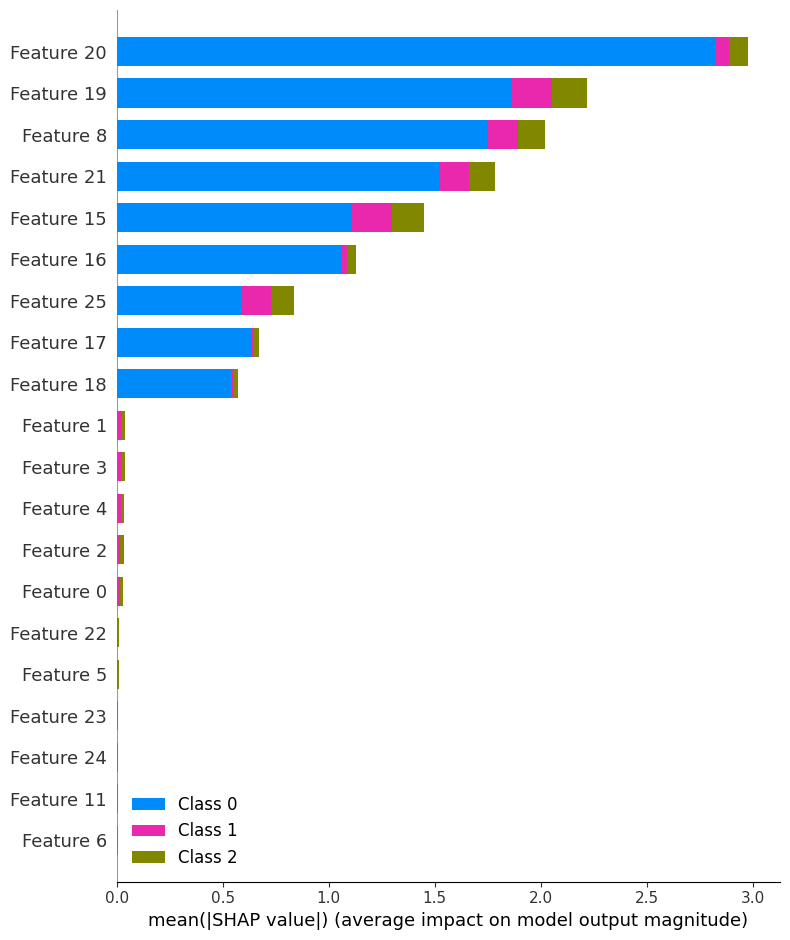

In [8]:
#BAR PLOT
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

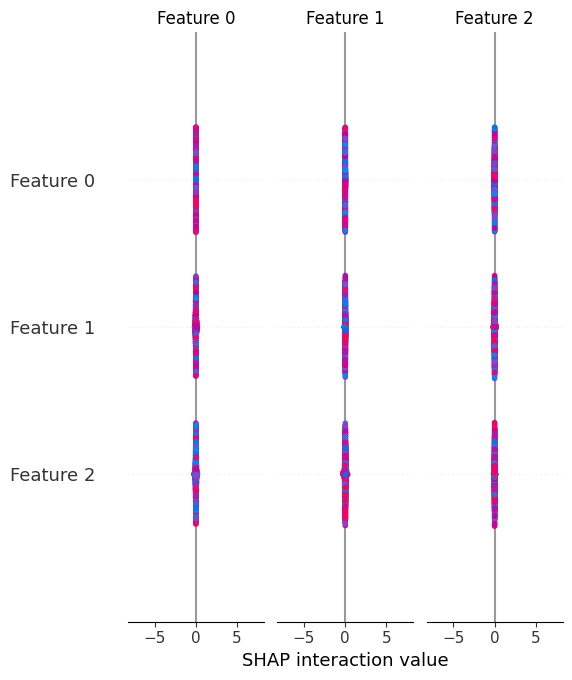

In [9]:
#BEESWARM PLOT
shap.summary_plot(
    shap_values,
    X_sample
)

In [10]:
feature_importance = np.mean(np.abs(shap_values), axis=(0, 2))

feature_names = [f"Feature_{i}" for i in range(X_test.shape[1])]

top_features = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

top_features = top_features.sort_values(
    by="Importance",
    ascending=False
)

top_features.head(10)

,Feature,Importance
20,Feature_20,0.993432
19,Feature_19,0.740285
8,Feature_8,0.672996
21,Feature_21,0.595508
15,Feature_15,0.483953
16,Feature_16,0.376046
25,Feature_25,0.278686
17,Feature_17,0.224251
18,Feature_18,0.191495
1,Feature_1,0.013407
